In [11]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json
import random

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_structures import Graph, BinarySearchTree
from src.brute_force import BruteForce
from src.greedy import Greedy
from src.performance_monitor import PerformanceMonitor
from src.visualizations import Visualizer

monitor = PerformanceMonitor()
visualizer = Visualizer()
print("Sistemas inicializados e prontos para operação.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Sistemas inicializados e prontos para operação.


--- RESULTADOS TEXTUAIS: CENÁRIO A ---
Custo Logístico Total da MST (Prim): 205.41


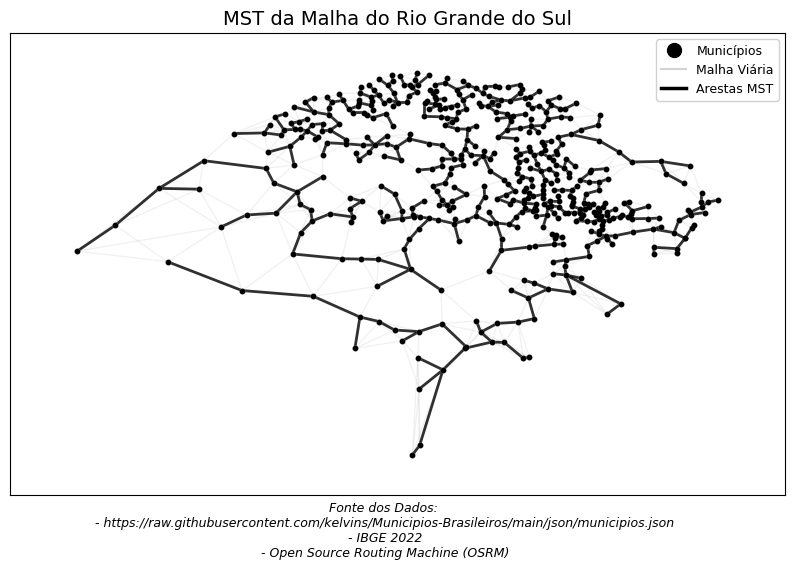


Rota mais rápida (4300034 -> 4323804): 4300034 -> 4309654 -> 4314506 -> 4314605 -> 4304507 -> 4301073 -> 4322327 -> 4306056 -> 4303509 -> 4305173 -> 4320552 -> 4301909 -> 4314902 -> 4303103 -> 4309209 -> 4309050 -> 4317608 -> 4313508 -> 4321600 -> 4323804
Tempo de viagem: 13.55 horas


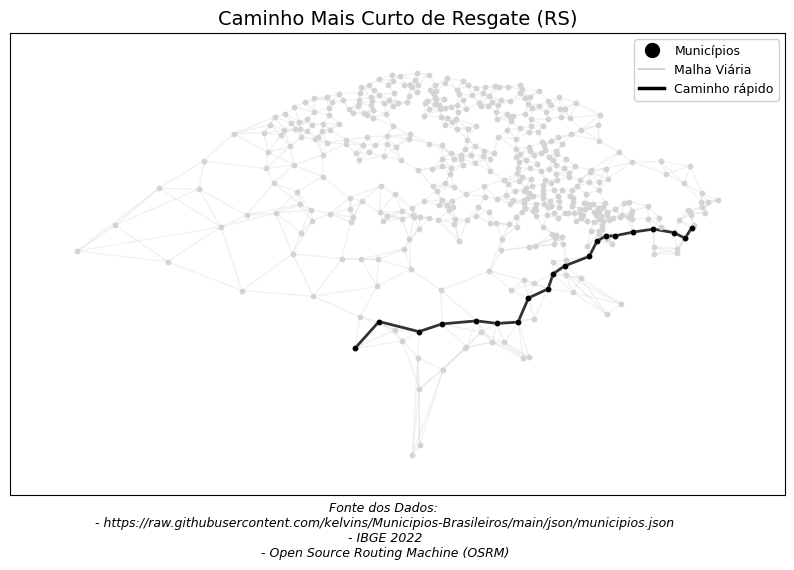

In [27]:
with open("../data/processed/graph_scenario_a.json", "r", encoding="utf-8") as f:
    dados_a = json.load(f)

grafo_rs = Graph()
positions = {}
for v_id, v_data in dados_a["vertices"].items():
    values = list(v_data.values())
    grafo_rs.add_municipality(str(v_data['id']), v_data['name'], v_data['risk_index'], v_data['service_cost'], v_data['population'])
    positions[v_id] = (v_data["lon"], v_data["lat"])

for v_id, vizinhos in dados_a["adjacency_list"].items():
    for vizinho_id, peso in vizinhos:
        grafo_rs.add_edge(str(v_id), str(vizinho_id), peso)

motor_rs = Greedy(grafo_rs)
nos_iniciais_rs = list(grafo_rs.vertices.keys())
hub_rs = nos_iniciais_rs[0]
cidade_isolada = nos_iniciais_rs[-1]

print("--- RESULTADOS TEXTUAIS: CENÁRIO A ---")
resultado_mst = motor_rs.find_minimum_spanning_tree(start_node=hub_rs)
print(f"Custo Logístico Total da MST (Prim): {resultado_mst['total_cost']:.2f}")
visualizer.plot_mst_graph(
    graph_dict=grafo_rs.get_graph(),
    positions=positions,
    mst_edges=resultado_mst["mst_edges"],
    title="MST da Malha do Rio Grande do Sul",
    data_source="\n- https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/json/municipios.json\n- IBGE 2022\n- Open Source Routing Machine (OSRM)",
    save_path="figura_1_cenario_a_mst.png"
)

bst_vazia = BinarySearchTree()
resultado_rota_a = motor_rs.find_best_path(hub_rs, cidade_isolada, bst_vazia)
caminho_a = resultado_rota_a['path']

print(f"\nRota mais rápida ({hub_rs} -> {cidade_isolada}): {' -> '.join(caminho_a)}")
print(f"Tempo de viagem: {resultado_rota_a['cost']:.2f} horas")

arestas_rota_a = [(caminho_a[i], caminho_a[i+1]) for i in range(len(caminho_a)-1)]
visualizer.plot_mst_graph(
    graph_dict=grafo_rs.get_graph(),
    positions=positions,
    mst_edges=arestas_rota_a,
    title="Caminho Mais Curto de Resgate (RS)",
    data_source="\n- https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/json/municipios.json\n- IBGE 2022\n- Open Source Routing Machine (OSRM)",
    is_path=True,
    save_path="figura_extra_cenario_a_rota.png"
)

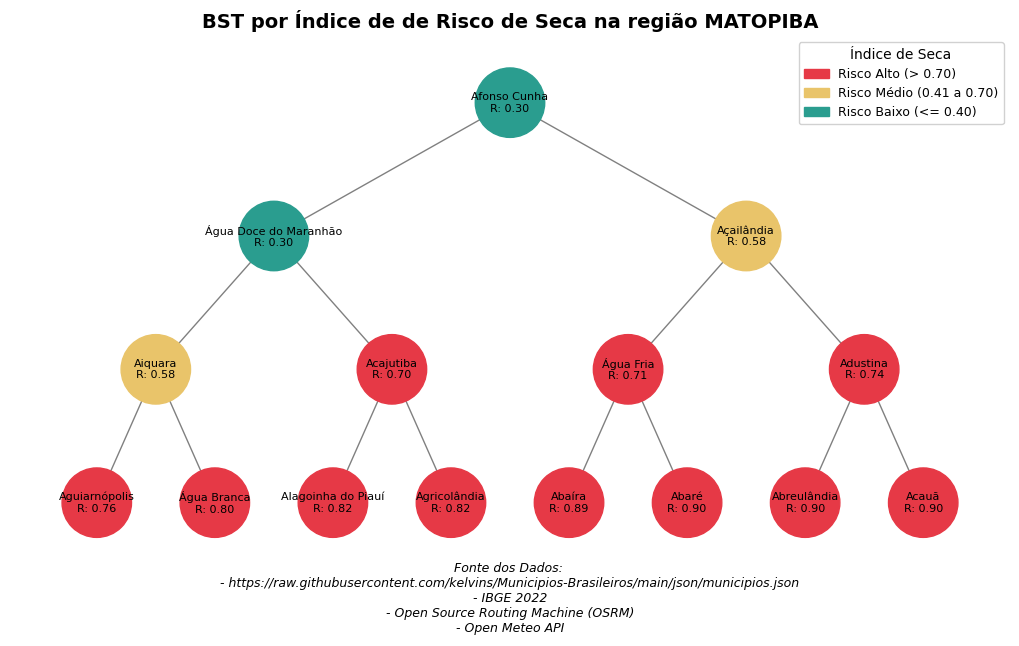


--- RESULTADOS TEXTUAIS: CENÁRIO B ---
Ordem de Despacho de Água (2900108 -> 2114007): 2900108 -> 2921906 -> 2901304 -> 2919306 -> 2914406 -> 2922052 -> 2906204 -> 2913101 -> 2932408 -> 2907608 -> 2933604 -> 2902708 -> 2904753 -> 2201101 -> 2203206 -> 2207603 -> 2202901 -> 2209757 -> 2206605 -> 2100501 -> 2112001 -> 2101400 -> 2104107 -> 2104099 -> 2104800 -> 2105476 -> 2101608 -> 2111672 -> 2108900 -> 2105807 -> 2108108 -> 2113009 -> 2107407 -> 2108702 -> 2101772 -> 2109908 -> 2102002 -> 2114007
Custo logístico ajustado (Com subsídio para áreas de seca): 36.48


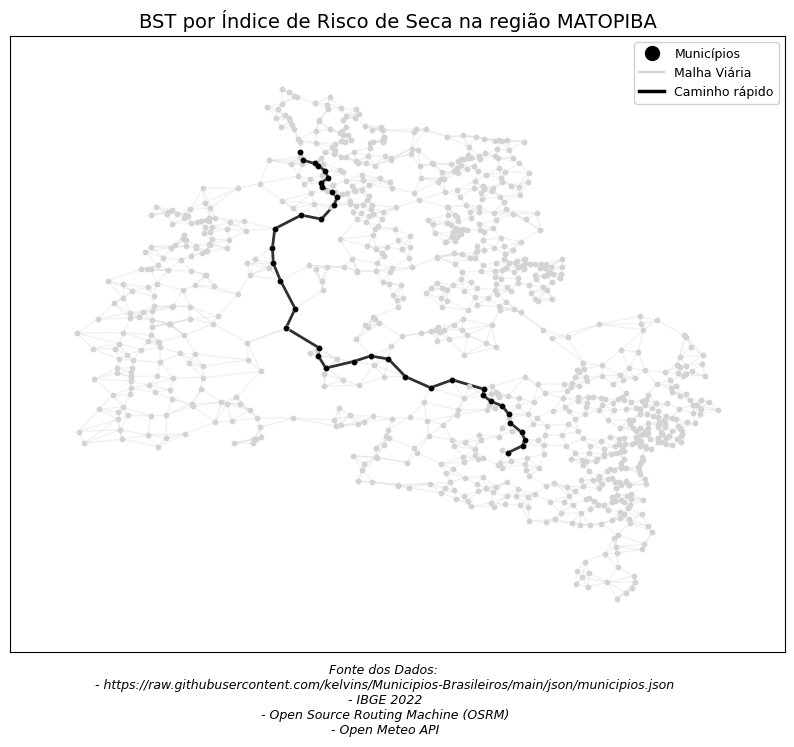

In [36]:
with open("../data/processed/graph_scenario_b.json", "r", encoding="utf-8") as f:
    dados_b_grafo = json.load(f)
with open("../data/processed/bst_scenario_b.json", "r", encoding="utf-8") as f:
    dados_b_bst = json.load(f)

grafo_matopiba = Graph()
for v_id, v_data in dados_b_grafo["vertices"].items():
    values = list(v_data.values())
    grafo_matopiba.add_municipality(str(v_data['id']), v_data['name'], v_data['risk_index'], v_data['service_cost'], v_data['population'])
    positions[v_id] = (v_data["lon"], v_data["lat"])

for v_id, vizinhos in dados_b_grafo["adjacency_list"].items():
    for vizinho_id, peso in vizinhos:
        grafo_matopiba.add_edge(str(v_id), str(vizinho_id), peso)

bst_matopiba = BinarySearchTree()
nos_para_plotar = []

for no_bst in dados_b_bst:
    if isinstance(no_bst, dict):
        valores_bst = list(no_bst.values())
    else:
        valores_bst = no_bst
        
    no_corrigido = (str(valores_bst[0]), valores_bst[1], valores_bst[2], valores_bst[3], valores_bst[4])
    
    bst_matopiba.insert(no_corrigido) 
    nos_para_plotar.append(no_corrigido)

visualizer.plot_bst_tree(
    bst_nodes_list=nos_para_plotar[:15],
    title="BST por Índice de de Risco de Seca na região MATOPIBA",
    data_source="\n- https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/json/municipios.json\n- IBGE 2022\n- Open Source Routing Machine (OSRM)\n- Open Meteo API",
    save_path="figura_2_cenario_b_bst.png"
)

motor_matopiba = Greedy(grafo_matopiba)
nos_matopiba = list(grafo_matopiba.vertices.keys())
origem_b = nos_matopiba[0]
destino_b = nos_matopiba[-1]

resultado_rota_b = motor_matopiba.find_best_path(origem_b, destino_b, bst_matopiba)
caminho_b = resultado_rota_b['path']

print("\n--- RESULTADOS TEXTUAIS: CENÁRIO B ---")
print(f"Ordem de Despacho de Água ({origem_b} -> {destino_b}): {' -> '.join(caminho_b)}")
print(f"Custo logístico ajustado (Com subsídio para áreas de seca): {resultado_rota_b['cost']:.2f}")

arestas_rota_b = [(caminho_b[i], caminho_b[i+1]) for i in range(len(caminho_b)-1)]
visualizer.plot_mst_graph(
    graph_dict=grafo_matopiba.get_graph(),
    positions=positions,
    mst_edges=arestas_rota_b,
    title="BST por Índice de Risco de Seca na região MATOPIBA",
    data_source="\n- https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/json/municipios.json\n- IBGE 2022\n- Open Source Routing Machine (OSRM)\n- Open Meteo API",
    is_path=True,
    save_path="figura_extra_cenario_b_rota.png"
)


--- INICIANDO BENCHMARK DE ESTRESSE (COMPLEXIDADE) ---
Avaliando explosão combinatória variando N de 4 a 12...
Aguarde, os últimos testes da Força Bruta vão forçar o processador...
[1/8] Testando instância N=4... 11.68812378747465 / 11.68812378747465
Concluído!
[2/8] Testando instância N=5... 16.528158664294587 / 16.528158664294587
Concluído!
[3/8] Testando instância N=6... 17.442616725625918 / 17.442616725625918
Concluído!
[4/8] Testando instância N=7... 9.274322076995269 / 9.274322076995269
Concluído!
[5/8] Testando instância N=8... 10.502592375187461 / 10.502592375187461
Concluído!
[6/8] Testando instância N=9... 15.746482710800173 / 15.746482710800173
Concluído!
[7/8] Testando instância N=10... 7.970536403823267 / 7.970536403823267
Concluído!
[8/8] Testando instância N=11... 6.886597867600409 / 6.886597867600409
Concluído!
Benchmarks finalizados! Gerando provas matemáticas...


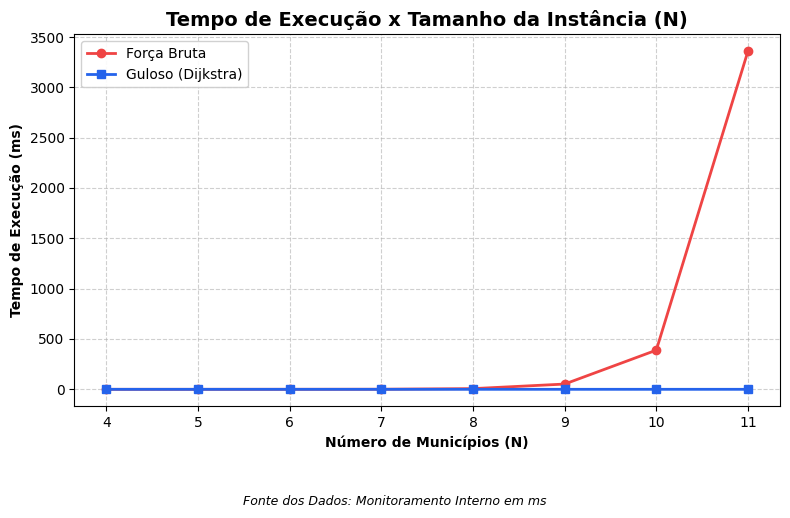

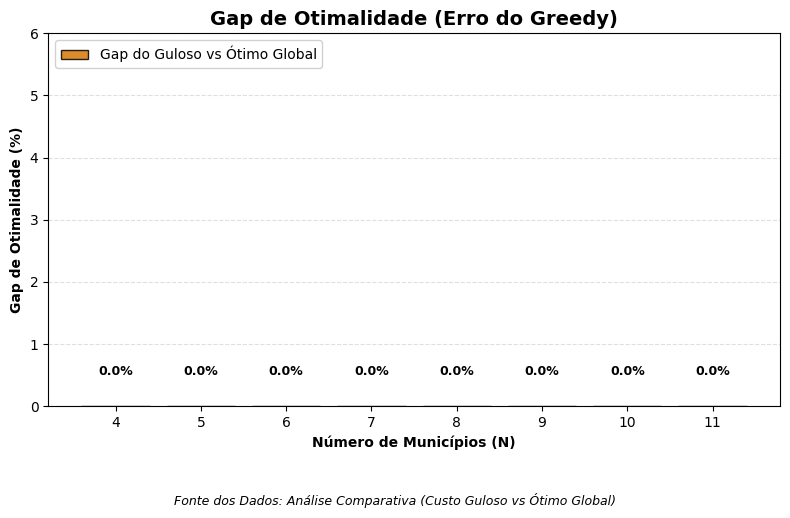

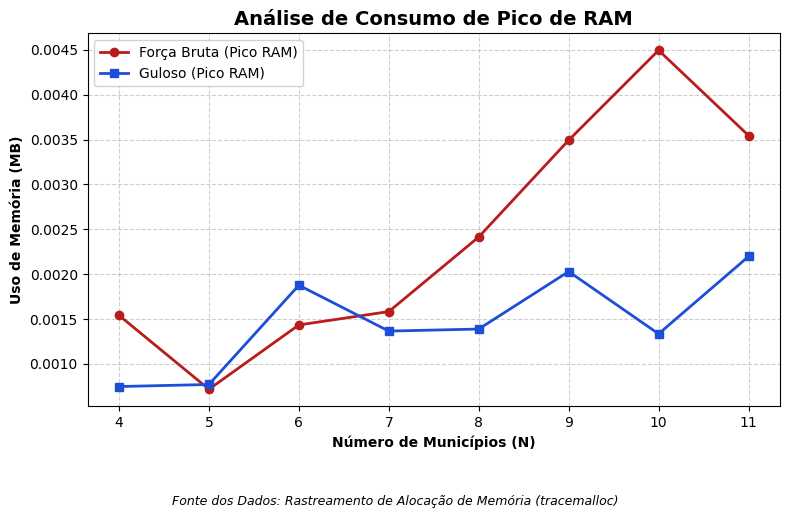

In [20]:
print("\n--- INICIANDO BENCHMARK DE ESTRESSE (COMPLEXIDADE) ---")
print("Avaliando explosão combinatória variando N de 4 a 12...")
print("Aguarde, os últimos testes da Força Bruta vão forçar o processador...")

monitor = PerformanceMonitor()
casos_de_teste = []
nos_rs = list(grafo_rs.vertices.keys())

for n in range(4, 12):
    mini_grafo = Graph()

    for v in range(n):
        mini_grafo.add_municipality(str(v), f"Cidade {v}", 0.0, 100, 1000)
    
    for u in range(n):
        for v in range(u + 1, n):
            peso = random.uniform(5.0, 20.0)
            mini_grafo.add_edge(str(u), str(v), peso)
            mini_grafo.add_edge(str(v), str(u), peso)

    fb_mini = BruteForce(mini_grafo)
    gr_mini = Greedy(mini_grafo)

    casos_de_teste.append({
        'N': n, 
        'origin': "0", 
        'dest': str(n - 1),
        'fb_finder': fb_mini,
        'gr_finder': gr_mini
    })

resultados_performance = monitor.run_benchmarks(casos_de_teste, bst_high_risk=BinarySearchTree())

print("Benchmarks finalizados! Gerando provas matemáticas...")

visualizer.plot_time_performance(
    resultados_performance, 
    "Tempo de Execução x Tamanho da Instância (N)", 
    "Monitoramento Interno em ms", 
    "figura_3_tempo.png"
)

visualizer.plot_optimality_gap(
    resultados_performance, 
    "Gap de Otimalidade (Erro do Greedy)", 
    "Análise Comparativa (Custo Guloso vs Ótimo Global)", 
    "figura_4_gap.png"
)

visualizer.plot_memory_performance(
    resultados_performance, 
    "Análise de Consumo de Pico de RAM", 
    "Rastreamento de Alocação de Memória (tracemalloc)", 
    "figura_extra_ram.png"
)